In [1]:
import pandas as pd
print("Hello, IELE756!")
print(f"pandas version: {pd.__version__}")

Hello, IELE756!
pandas version: 3.0.1


# Tarea 0 --- IELE756
**Team members**: [Benjamín Soto], [Isidora Riquelme]
**Region**: [Región Metropolitana]
**Date**: [15/03/2026]

Part 0: Setup (1 pt)


In [12]:
import pandas as pd

persona = pd.read_parquet(
    "../Datos/personas_censo2024.parquet",
    columns=["region", "comuna", "sexo", "edad",
             "p27_nacionalidad", "p27_nacionalidad_rec",
             "escolaridad", "sit_fuerza_trabajo"],
)

In [13]:
persona.shape

(18480432, 8)

In [14]:
persona.dtypes

region                    int32
comuna                    int32
sexo                      int32
edad                      int32
p27_nacionalidad          int32
p27_nacionalidad_rec      int32
escolaridad               int32
sit_fuerza_trabajo      float64
dtype: object

In [15]:
persona.head(10)

,region,comuna,sexo,edad,p27_nacionalidad,p27_nacionalidad_rec,escolaridad,sit_fuerza_trabajo
0,5,5802,2,80,1,1,17,3.0
1,5,5802,1,52,1,1,14,1.0
2,5,5802,2,45,1,1,12,1.0
3,5,5802,2,8,1,1,2,NaN
4,4,4303,1,69,1,1,12,3.0
5,4,4303,2,65,1,1,12,3.0
6,4,4303,1,58,1,1,15,1.0
7,11,11202,2,-66,-66,1,8,1.0
8,11,11202,1,-66,-66,1,5,1.0
9,11,11202,1,-66,-66,1,3,NaN


In [16]:
persona.info()

<class 'pandas.DataFrame'>
RangeIndex: 18480432 entries, 0 to 18480431
Data columns (total 8 columns):
 #   Column                Dtype  
---  ------                -----  
 0   region                int32  
 1   comuna                int32  
 2   sexo                  int32  
 3   edad                  int32  
 4   p27_nacionalidad      int32  
 5   p27_nacionalidad_rec  int32  
 6   escolaridad           int32  
 7   sit_fuerza_trabajo    float64
dtypes: float64(1), int32(7)
memory usage: 634.5 MB


In [17]:
my_region = persona[persona["region"] == 13]
print(f"Rows in my region: {len(my_region):,}")

Rows in my region: 7,400,741


In [18]:
foreign = my_region["p27_nacionalidad_rec"] \
.value_counts(normalize=True)
print(f"% foreign-born: {foreign.get(2, 0):.1%}")

% foreign-born: 12.2%


In [19]:
my_region["p27_nacionalidad_rec"].value_counts()

p27_nacionalidad_rec
 1     6446621
 2      904819
-99      49301
Name: count, dtype: int64

Part 2: ENO --- Notifiable Diseases (1.5 pts)


In [20]:
import pandas as pd

eno = pd.read_csv(
    "../Datos/20241218_base_eno_final.csv",
    sep=";", encoding="utf-8-sig")
print(f"Total rows: {len(eno):,}")
print(eno.columns.tolist())

C:\Users\benja\AppData\Local\Temp\ipykernel_29932\406378566.py:3: DtypeWarning: Columns (0: Autóctono, 1: presenta_sintomas, 2: sintomas, 3: consumo_agua_no_potable, 4: antecedente_teniasis, 5: imagenologia, 6: manifestaciones, 7: existe_coinfeccion, 8: via_transmision, 9: n_parejas_sexuales, 10: uso_preservativo, 11: paciente_inmunosuprimido, 12: vih, 13: pareja, 14: exantema_mpox, 15: factores_exposicion, 16: neumonia, 17: contacto_aves, 18: genotipo_1, 19: recuento_linfocitos, 20: clasificacion_final_vih, 21: etapa_vih_sida, 22: hospitalizacion, 23: nombre_primer_sintoma, 24: SeroGrupo) have mixed types. Specify dtype option on import or set low_memory=False.
  eno = pd.read_csv(


Total rows: 333,300
['etapa_clinica', 'region', 'seremi', 'nacionalidad', 'cie_10_diagnostico', 'diagnostico', 'Autóctono', 'anho_notificacion', 'ENO', 'pueblo_indigena', 'nombre_instruccion', 'presenta_sintomas', 'sintomas', 'consumo_agua_no_potable', 'antecedente_teniasis', 'imagenologia', 'manifestaciones', 'existe_coinfeccion', 'via_transmision', 'n_parejas_sexuales', 'uso_preservativo', 'pais_contagio', 'paciente_inmunosuprimido', 'vih', 'pareja', 'exantema_mpox', 'factores_exposicion', 'neumonia', 'contacto_aves', 'genotipo_1', 'recuento_linfocitos', 'clasificacion_final_vih', 'etapa_vih_sida', 'hospitalizacion', 'nombre_primer_sintoma', 'SeroGrupo', 'sexo', 'grupo_edad', 'codigo_comuna_residencia']


In [23]:
eno_region = eno[eno["region"] == "Región Metropolitana de Santiago"]
print(f"Rows in my region: {len(eno_region):,}")

Rows in my region: 126,669


In [24]:
eno_region["anho_notificacion"].value_counts().sort_index()

anho_notificacion
2007     3930
2008     3830
2009     4015
2010     4693
2011     6151
2012     5857
2013     6006
2014     6005
2015     6129
2016     6023
2017    10865
2018    13256
2019    10287
2020     7182
2021     7457
2022    10496
2023     9395
2024     5092
Name: count, dtype: int64

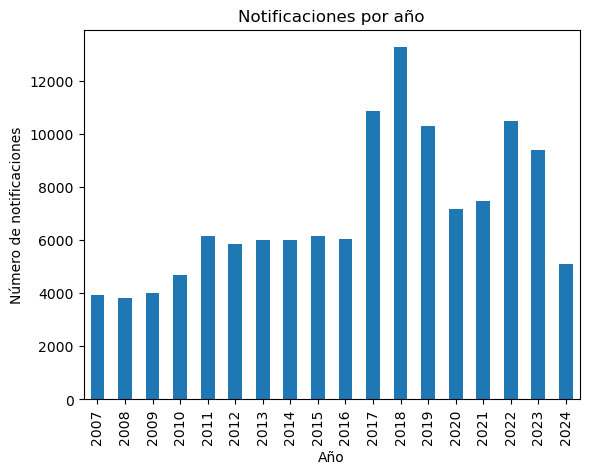

In [25]:
import matplotlib.pyplot as plt

notificaciones = eno_region["anho_notificacion"].value_counts().sort_index()

notificaciones.plot(kind="bar")

plt.title("Notificaciones por año")
plt.xlabel("Año")
plt.ylabel("Número de notificaciones")

plt.show()

In [26]:
eno_region["ENO"].value_counts().head(5)

ENO
Sifilis                 40928
VIH                     29097
Parotiditis             15493
Infección gonocócica     8766
Hepatitis B              7565
Name: count, dtype: int64

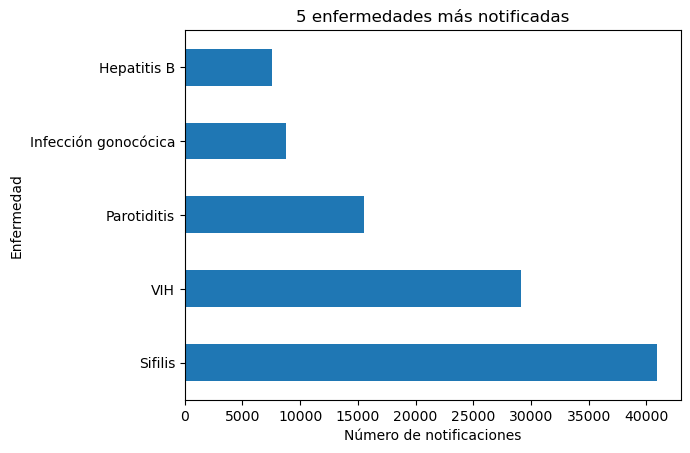

In [27]:
import matplotlib.pyplot as plt

frecuent5 = eno_region["ENO"].value_counts().head(5)

frecuent5.plot(kind="barh")

plt.title("5 enfermedades más notificadas")
plt.xlabel("Número de notificaciones")
plt.ylabel("Enfermedad")

plt.show()

In [28]:
eno_region["nacionalidad"].value_counts()


nacionalidad
Desconocido    55863
Chile          47093
Extranjero     23713
Name: count, dtype: int64

Part 3: GRD --- Hospital Discharges (1 pt)


In [29]:
import zipfile
import pandas as pd

cols = ["COMUNA", "NACIONALIDAD", "SEXO", "DIAGNOSTICO1",
        "FECHA_INGRESO", "FECHAALTA",
        "IR_29301_SEVERIDAD", "IR_29301_COD_GRD"]

with zipfile.ZipFile("../Datos/GRD_PUBLICO_2024.zip") as z:
    with z.open("GRD_PUBLICO_2024.txt") as f:
        grd = pd.read_csv(
            f,
            sep="|",
            usecols=cols,
            encoding="latin1",
            low_memory=False
        )

print(f"Total discharges: {len(grd):,}")
print(grd.head())

Total discharges: 1,085,813
     SEXO               COMUNA NACIONALIDAD FECHA_INGRESO   FECHAALTA  \
0   MUJER        VILLA ALEMANA        CHILE    2024-03-23  2024-03-23   
1   MUJER         VIÑA DEL MAR        CHILE    2024-09-26  2024-10-02   
2  HOMBRE            LA SERENA        CHILE    2024-01-22  2024-01-26   
3  HOMBRE                ÑUÑOA        CHILE    2024-04-08  2024-04-14   
4   MUJER  SAN PEDRO DE LA PAZ         PERÚ    2024-09-24  2024-09-26   

  DIAGNOSTICO1 IR_29301_COD_GRD IR_29301_SEVERIDAD  
0        H26.9           022360                  0  
1        M31.1           041023                  3  
2        K12.2           034141                  1  
3          C61           061203                  3  
4        K35.8           061131                  1  


In [36]:
my_comunas = ["COLINA", "MELIPILLA", "TALAGANTE"]  # your region's comunas
grd_region = grd[grd["COMUNA"].isin(my_comunas)]
print(f"Discharges in my region: {len(grd_region):,}")

Discharges in my region: 20,255


In [39]:
cie10 = pd.read_excel("../Datos/CIE-10.xlsx",
                       sheet_name="CIE 10")

grd_region = grd_region.merge(
    cie10[["Código", "Descripción", "Capítulo"]],
    left_on="DIAGNOSTICO1", right_on="Código",
    how="left")

grd_region["Descripción"].value_counts().head(5)

Descripción
Catarata, no especificada                                        783
Cálculo de la vesícula biliar sin colecistitis                   526
Apendicitis aguda, otra y no especificada                        376
Atención materna por cicatriz uterina debida a cirugía previa    258
Neumonía, no especificada                                        229
Name: count, dtype: int64

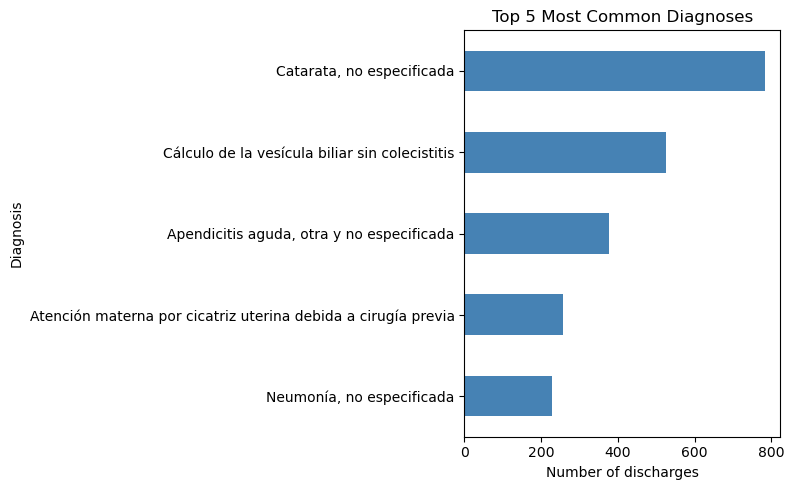

In [42]:
top5 = grd_region["Descripción"].value_counts().head(5)

plt.figure(figsize=(8,5))
top5.plot(kind="barh", color="steelblue")

plt.title("Top 5 Most Common Diagnoses")
plt.xlabel("Number of discharges")
plt.ylabel("Diagnosis")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()